# Figure 5 — reliability diagrams (C1 and C4)

Fifteen-bin expected calibration error (ECE) reliability plots on **calibrated** test probabilities (`ece_15_bins_temperature_scaled` from Virchow eval JSON).

- **C1:** PCam-trained → PCam test (in-domain)
- **C4:** CAMELYON17-trained → PCam test (external)

**Output:** `reports/figures/figure5_virchow_reliability_c1_c4.png` and `.pdf` (300 dpi).

In [4]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_cwd = Path.cwd().resolve()
REPO = _cwd if (_cwd / "experiments").is_dir() else _cwd.parent
if not (REPO / "experiments").is_dir():
    REPO = Path(r"C:\GP_ECG")

EVAL_ROOT = REPO / "experiments" / "virchow_colab" / "evals_cross_domain"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PANELS = {
    "C1": {
        "folder": EVAL_ROOT / "pcam_trained_on_pcam_test",
        "title": "C1: PCam → PCam test",
    },
    "C4": {
        "folder": EVAL_ROOT / "cam17_trained_on_pcam_test",
        "title": "C4: CAMELYON17 → PCam test",
    },
}

DPI = 300
FIG_PNG = FIG_DIR / "figure5_virchow_reliability_c1_c4.png"
FIG_PDF = FIG_DIR / "figure5_virchow_reliability_c1_c4.pdf"

print("REPO:", REPO)
for cid, meta in PANELS.items():
    p = meta["folder"] / "test_metrics_detailed.json"
    print(cid, p, "exists:", p.is_file())

REPO: C:\GP_ECG
C1 C:\GP_ECG\experiments\virchow_colab\evals_cross_domain\pcam_trained_on_pcam_test\test_metrics_detailed.json exists: True
C4 C:\GP_ECG\experiments\virchow_colab\evals_cross_domain\cam17_trained_on_pcam_test\test_metrics_detailed.json exists: True


In [5]:
def load_ece_bins(metrics_path: Path) -> dict:
    with metrics_path.open(encoding="utf-8") as f:
        data = json.load(f)
    ece = data.get("ece_15_bins_temperature_scaled")
    if ece is None:
        raise KeyError(f"ece_15_bins_temperature_scaled not in {metrics_path}")
    return ece


def bin_arrays(ece: dict) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return bin_centers, conf, acc, counts for non-empty bins."""
    centers, confs, accs, counts = [], [], [], []
    for b in ece["bins"]:
        n = int(b.get("n", 0))
        if n == 0 or b.get("conf") is None or b.get("acc") is None:
            continue
        lo, hi = b["bin"]
        centers.append(0.5 * (lo + hi))
        confs.append(float(b["conf"]))
        accs.append(float(b["acc"]))
        counts.append(n)
    return (
        np.array(centers),
        np.array(confs),
        np.array(accs),
        np.array(counts, dtype=int),
    )


def plot_reliability(ax, ece: dict, title: str) -> None:
    _, conf, acc, counts = bin_arrays(ece)
    ax.plot([0, 1], [0, 1], color="#666666", linestyle="--", linewidth=1.2, label="Perfect calibration")
    for c, a in zip(conf, acc):
        ax.plot([c, c], [a, c], color="#c44e52", alpha=0.35, linewidth=1.0, zorder=1)
    sizes = 12 + 80 * (counts / max(counts.max(), 1))
    ax.scatter(conf, acc, s=sizes, c="#1f77b4", edgecolors="white", linewidths=0.4, zorder=3, label="Bins")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Mean predicted probability (bin)")
    ax.set_ylabel("Fraction positive (bin accuracy)")
    ax.set_title(f"{title}\nECE₁₅ = {ece['ece']:.3f}", fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9)


ece_by_panel = {cid: load_ece_bins(meta["folder"] / "test_metrics_detailed.json") for cid, meta in PANELS.items()}
for cid, ece in ece_by_panel.items():
    print(f"{cid} ECE_15 = {ece['ece']:.4f}")

C1 ECE_15 = 0.0200
C4 ECE_15 = 0.1600


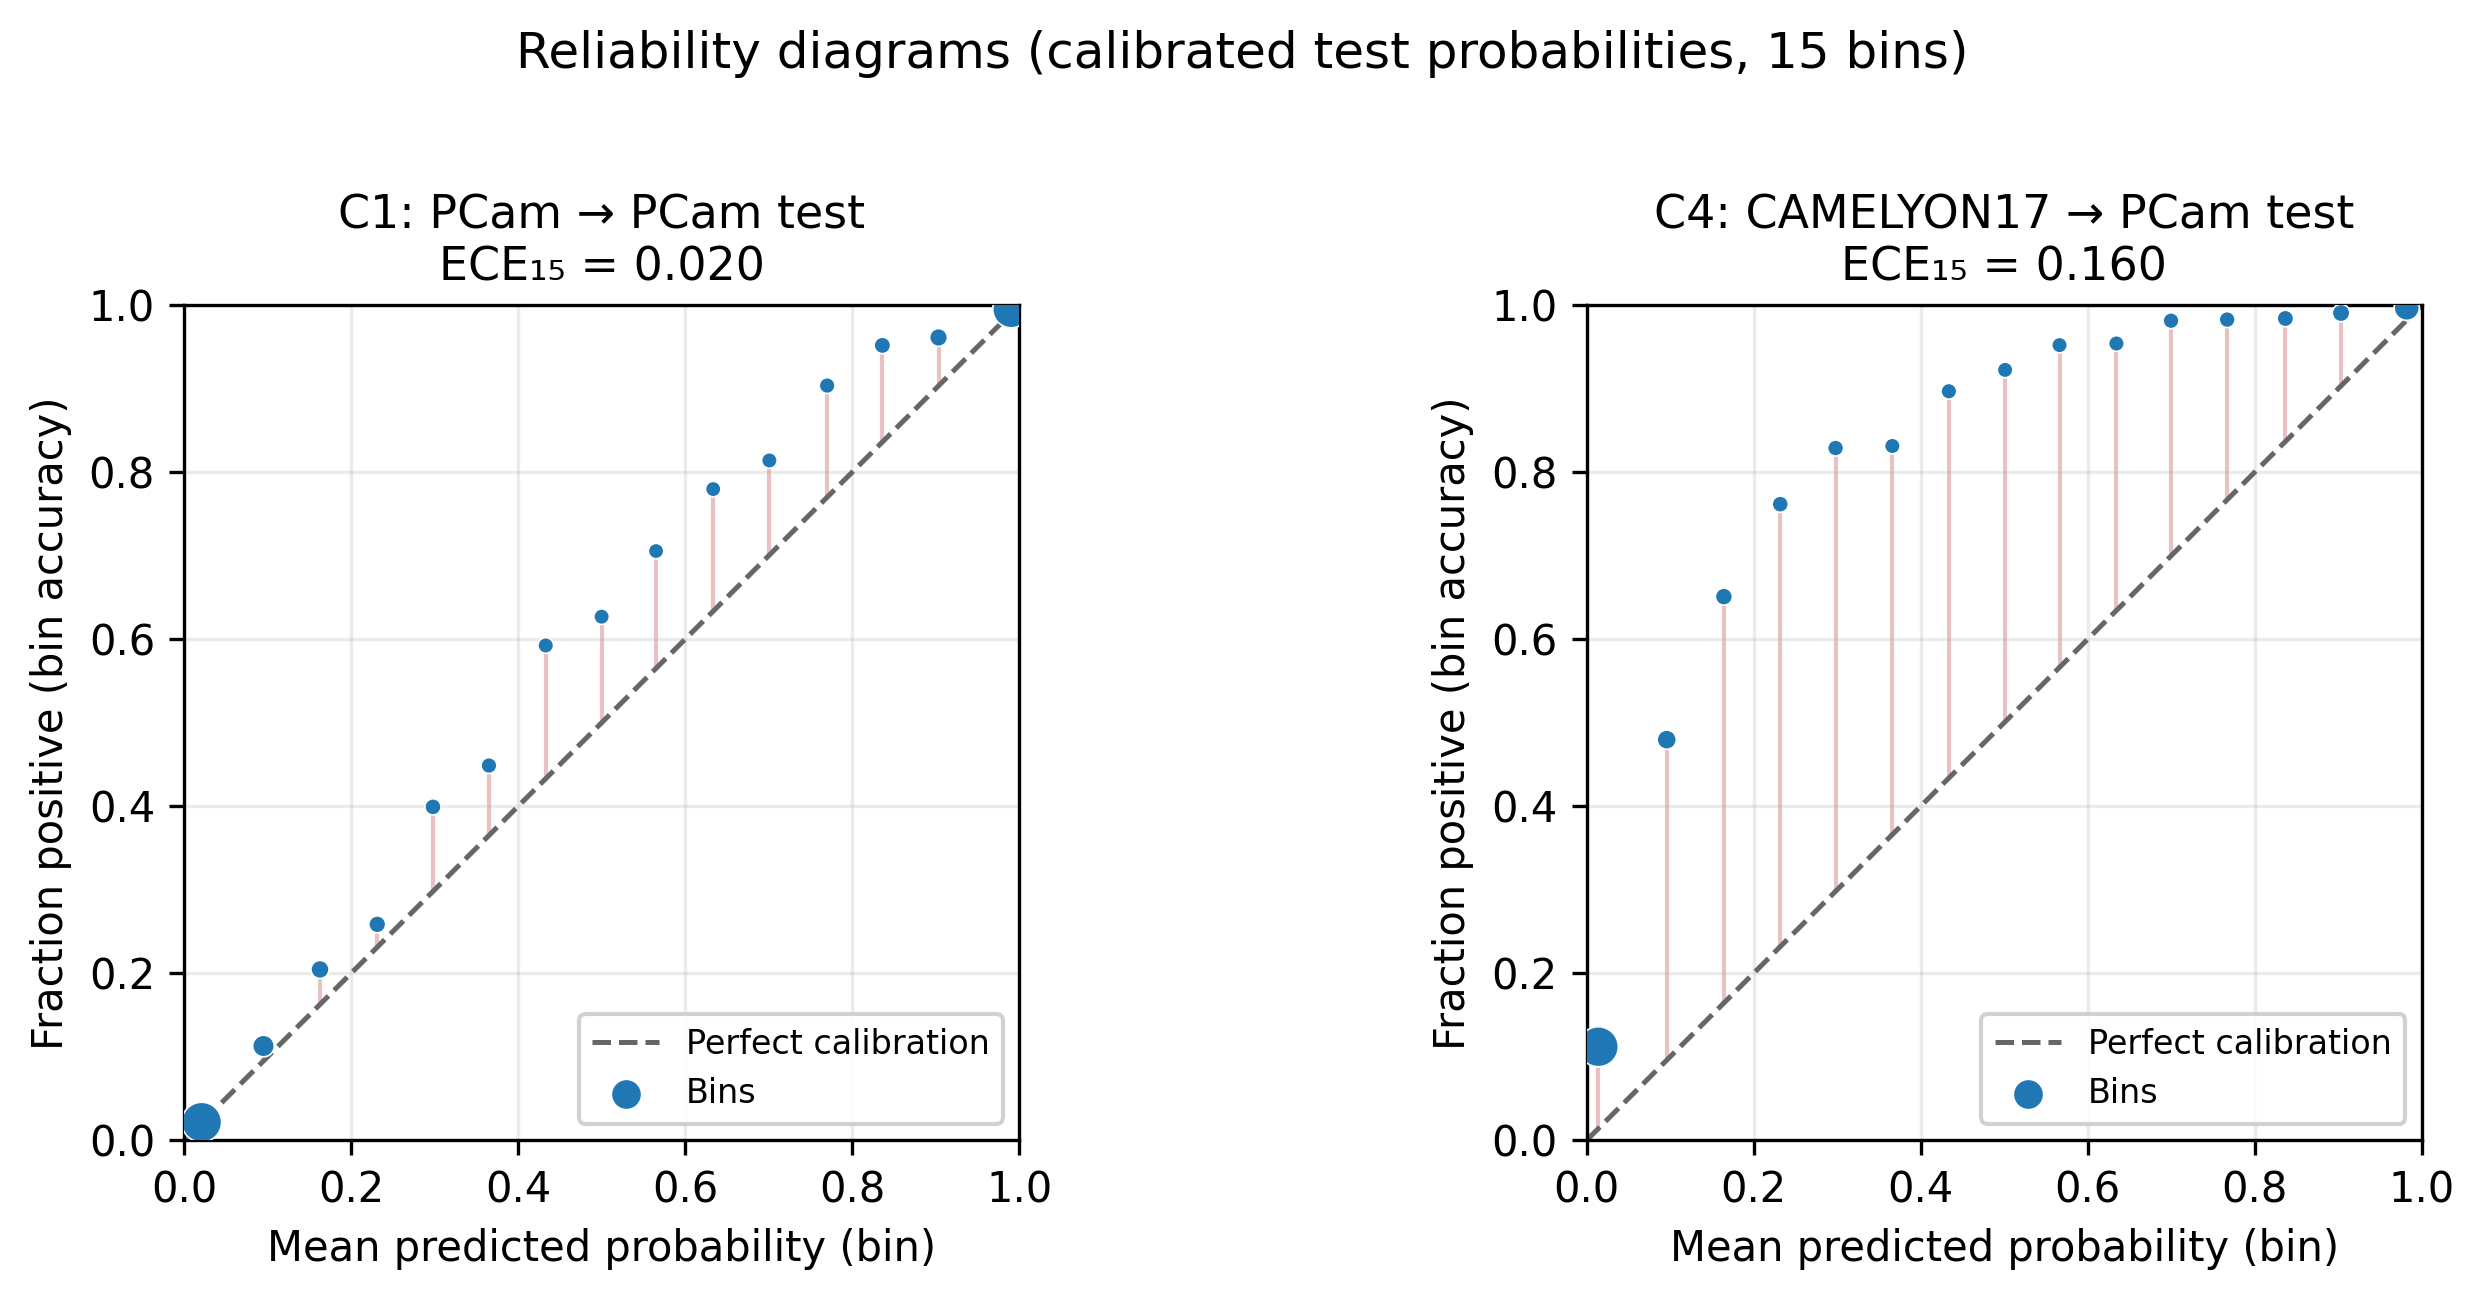

Saved: C:\GP_ECG\reports\figures\figure5_virchow_reliability_c1_c4.png
Saved: C:\GP_ECG\reports\figures\figure5_virchow_reliability_c1_c4.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), dpi=DPI)
for ax, (cid, meta) in zip(axes, PANELS.items()):
    plot_reliability(ax, ece_by_panel[cid], meta["title"])

fig.suptitle("Reliability diagrams (calibrated test probabilities, 15 bins)", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIG_PNG, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_PDF, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIG_PNG)
print("Saved:", FIG_PDF)